Loaded volume with shape (slices, H, W): (133, 512, 512)


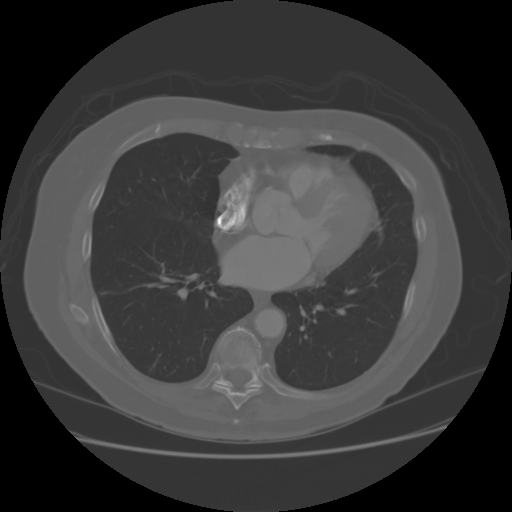

In [1]:
# If you need Pillow, install it:
# !pip install Pillow

import os
import numpy as np
import pydicom
from PIL import Image
from IPython.display import display

# 1) Point to your series folder
PATIENT_DIR = "../LIDC-IDRI-Dataset/manifest-1600709154662/LIDC-IDRI/LIDC-IDRI-0001/01-01-2000-NA-NA-30178/3000566.000000-NA-03192"
XML_FILE = "../LIDC-IDRI-Dataset/manifest-1600709154662/LIDC-IDRI/LIDC-IDRI-0001/01-01-2000-NA-NA-30178/3000566.000000-NA-03192/069.xml"

# 2) Gather all .dcm files
dcm_paths = [
    os.path.join(root, f)
    for root, _, files in os.walk(PATIENT_DIR)
    for f in files
    if f.lower().endswith(".dcm")
]
if not dcm_paths:
    raise FileNotFoundError(f"No DICOM files found under {PATIENT_DIR}")

# 3) Read & sort by slice order
slices = sorted(
    (pydicom.dcmread(p) for p in dcm_paths),
    key=lambda ds: int(ds.InstanceNumber)
)

# 4) Build 3D volume
volume = np.stack([s.pixel_array for s in slices], axis=0)
print(f"Loaded volume with shape (slices, H, W): {volume.shape}")

# 5) Pick the middle slice and normalize to 0–255
mid_idx = volume.shape[0] // 2
slice_img = volume[mid_idx].astype(np.float32)
slice_img = (slice_img - slice_img.min()) / (slice_img.ptp())  # normalize to 0–1
slice_img = (slice_img * 255).astype(np.uint8)                 # to 0–255

# 6) Convert to PIL Image and display
img = Image.fromarray(slice_img)
display(img)
